<a href="https://colab.research.google.com/github/shaitanshaitan/Winc-Academy-DA-with-Python-2.0/blob/main/Project_CO2_Emissions_Assignment_Question_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project CO2 Emissions Assignment Winc Academy**

**Question 3 (Q3):**

Which non-fossil fuel energy technology will have the best price in the future?

*   Predict prices and use linear regression over the various non-fossil fuel options.

**dataset used**

Q3: Which non-fossil fuel energy technology will have the best price in the future?

dataset 1:

levelized-cost-of-energy.csv

**Approach**
Filter World data → split into two groups by data availability →
visualize raw trends → apply linear regression → predict prices to 2035 →
identify cheapest technology

**Groups**

- Group 1: Wind technologies (Onshore 2000-2024, Offshore 2013-2024)
- Group 2: Solar PV, CSP, Bioenergy, Geothermal, Hydropower (2010-2024)


In [1]:
# basis imports for this project

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

from datetime import datetime as dt
from scipy.stats import pearsonr

**Assignment Three: Which non-fossil fuel energy technology will have the best price in the future?**

In [2]:
base_url = 'https://github.com/shaitanshaitan/Winc-Academy-DA-with-Python-2.0'

In [3]:
df_level = pd.read_csv(f'https://raw.githubusercontent.com/shaitanshaitan/Winc-Academy-DA-with-Python-2.0/refs/heads/main/levelized-cost-of-energy.csv').copy()

**Check Datasets & Cleaning Data**

In [4]:
# checking dataset line by line

df_level.head()
# df_level.describe()
# df_level.isnull().sum()

,Entity,Code,Year,Bioenergy,Geothermal,Offshore wind,Solar photovoltaic,Concentrated solar power,Hydropower,Onshore wind
0,Argentina,ARG,1995,NaN,NaN,NaN,NaN,NaN,NaN,0.287333
1,Argentina,ARG,1997,NaN,NaN,NaN,NaN,NaN,NaN,0.146460
2,Argentina,ARG,2008,NaN,NaN,NaN,NaN,NaN,NaN,0.563346
3,Argentina,ARG,2009,NaN,NaN,NaN,NaN,NaN,NaN,0.317437
4,Argentina,ARG,2012,NaN,NaN,NaN,NaN,NaN,NaN,0.122855


In [5]:
df_level.drop(columns=['Code'], axis=1, inplace=True)

In [6]:
# create full overview by [print] of the dataset
# many missing values to address

print(df_level.shape)
print(df_level.columns.tolist())
print(df_level.head(5))
print(df_level.isnull().sum())

(852, 9)
['Entity', 'Year', 'Bioenergy', 'Geothermal', 'Offshore wind', 'Solar photovoltaic', 'Concentrated solar power', 'Hydropower', 'Onshore wind']
      Entity  Year  Bioenergy  Geothermal  Offshore wind  Solar photovoltaic  \
0  Argentina  1995        NaN         NaN            NaN                 NaN   
1  Argentina  1997        NaN         NaN            NaN                 NaN   
2  Argentina  2008        NaN         NaN            NaN                 NaN   
3  Argentina  2009        NaN         NaN            NaN                 NaN   
4  Argentina  2012        NaN         NaN            NaN                 NaN   

   Concentrated solar power  Hydropower  Onshore wind  
0                       NaN         NaN      0.287333  
1                       NaN         NaN      0.146460  
2                       NaN         NaN      0.563346  
3                       NaN         NaN      0.317437  
4                       NaN         NaN      0.122855  
Entity                        0

To answer the question I need to calculate the average price on worldbase and not on country base.

In [7]:
# check if world data is in dataset = Filter: Entity is World

print(df_level[df_level['Entity'] == 'World'])

    Entity  Year  Bioenergy  Geothermal  Offshore wind  Solar photovoltaic  \
811  World  1984        NaN         NaN            NaN                 NaN   
812  World  1985        NaN         NaN            NaN                 NaN   
813  World  1986        NaN         NaN            NaN                 NaN   
814  World  1987        NaN         NaN            NaN                 NaN   
815  World  1988        NaN         NaN            NaN                 NaN   
816  World  1989        NaN         NaN            NaN                 NaN   
817  World  1990        NaN         NaN            NaN                 NaN   
818  World  1991        NaN         NaN            NaN                 NaN   
819  World  1992        NaN         NaN            NaN                 NaN   
820  World  1993        NaN         NaN            NaN                 NaN   
821  World  1994        NaN         NaN            NaN                 NaN   
822  World  1995        NaN         NaN            NaN          

In [8]:
# how does the world DF look like

df_world = df_level[df_level['Entity'] == 'World'].copy()
print(df_world.shape)
print(df_world.isnull().sum())
print(df_world.head())

(41, 9)
Entity                       0
Year                         0
Bioenergy                   26
Geothermal                  24
Offshore wind               16
Solar photovoltaic          26
Concentrated solar power    26
Hydropower                  26
Onshore wind                 0
dtype: int64
    Entity  Year  Bioenergy  Geothermal  Offshore wind  Solar photovoltaic  \
811  World  1984        NaN         NaN            NaN                 NaN   
812  World  1985        NaN         NaN            NaN                 NaN   
813  World  1986        NaN         NaN            NaN                 NaN   
814  World  1987        NaN         NaN            NaN                 NaN   
815  World  1988        NaN         NaN            NaN                 NaN   

     Concentrated solar power  Hydropower  Onshore wind  
811                       NaN         NaN      0.358735  
812                       NaN         NaN      0.333092  
813                       NaN         NaN      0.295648  

There is a big gap in datapoints between Wind technology and the other technologies. There for I will split the analyses in Onshore only and the other 6 technologies.

Wind technology
*   Onshore wind 45 years
*   Offshore wind 25 years

Other technologies
*   Geothermal 17 years
*   Solar photvoltaic 15 years
*   Concentraded solar power 15 years
*   Hydropower 15 years
*   Bioenergy 15 years






To make good descion on which datapoints to use I want to know what datapoints i actually can use per group, espcially which years.

Code below

In [9]:
# years in dataset per technology

df_world = df_level[df_level['Entity'] == 'World'].copy()

technologies = ['Bioenergy', 'Geothermal', 'Offshore wind',
                'Solar photovoltaic', 'Concentrated solar power',
                'Hydropower', 'Onshore wind']

for tech in technologies:
    df_tech = df_world.dropna(subset=[tech])
    print(f'{tech}: {df_tech["Year"].min()} - {df_tech["Year"].max()} ({len(df_tech)} years)')

Bioenergy: 2010 - 2024 (15 years)
Geothermal: 2007 - 2024 (17 years)
Offshore wind: 2000 - 2024 (25 years)
Solar photovoltaic: 2010 - 2024 (15 years)
Concentrated solar power: 2010 - 2024 (15 years)
Hydropower: 2010 - 2024 (15 years)
Onshore wind: 1984 - 2024 (41 years)


Looking at the datapoints I still want to split the analyses and go for Wind technology versus other technologies. Onshore wind is measured from 1984 but  Offshore technology has been matured from 2000. So for the wind technology analysis i will use the years 2000-2024 (25 years).

For the other technologies i take 15 years as the baseline, taking 2010-2024 for the 5 technologies other than wind technology

**Analysis Question 3: Which non-fossil fuel energy technology will have the best price in the future?**

- Group 1: How have wind technologies evolved since 2000?
- Group 2: How are newer technologies competing since 2010?
→ Which will be cheapest by 2030/2035?

In [10]:
# Group 1: Wind technology price evolution 2000-2024 (25 years)

# filtering dataset (years)
df_wind = df_world[(df_world['Year'] >= 2000) & (df_world['Year'] <= 2024)].copy()

# filtering technologies (wind)
df_wind = df_wind[['Year', 'Onshore wind', 'Offshore wind']].copy()

print(df_wind.shape)
print(df_wind.isnull().sum())
print(df_wind.head())

(25, 3)
Year             0
Onshore wind     0
Offshore wind    0
dtype: int64
     Year  Onshore wind  Offshore wind
827  2000      0.178808       0.185067
828  2001      0.156931       0.175034
829  2002      0.145083       0.148301
830  2003      0.127091       0.136784
831  2004      0.129223       0.194058


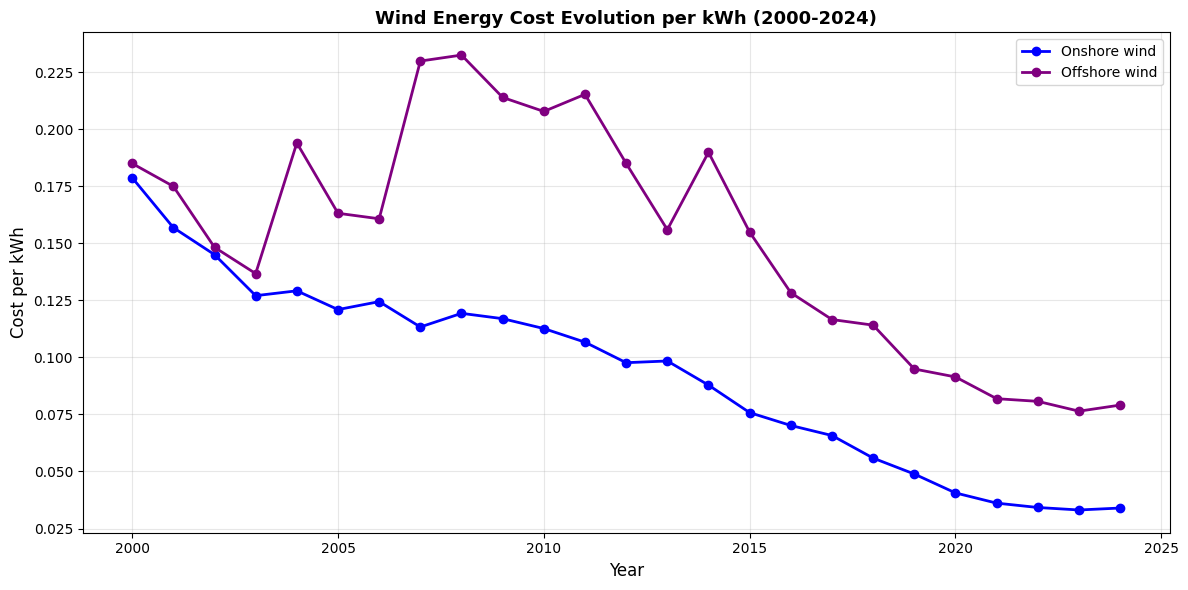

In [11]:
# Evaluating raw output before regression analyses on outliers and validity

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df_wind['Year'], df_wind['Onshore wind'], marker='o', linewidth=2, label='Onshore wind',
        color='blue')
ax.plot(df_wind['Year'], df_wind['Offshore wind'], marker='o', linewidth=2,
        label='Offshore wind', color='purple')

ax.set_title('Wind Energy Cost Evolution per kWh (2000-2024)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Cost per kWh', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



Key observations:

- Onshore windSteady decline, very consistent downward trend
- Offshore windVolatile until 2013, then clear downward trend to $0.08
- Offshore wind volatile until 2013-2015, then clear downward trend

To build a prediction for future price Onshore wind technology has the most steady datapoints and a clear regression line can be drawn. For Offshore wind technology a steady trend appears to be from 2013 and onwards, before 2013-2015 cost were high to build offshore wind farms, the technology wasn't matured. From 2015 the market and technologies stabalized.

We will do two analyses for wind technology. 1. based offshore and onshore between 2000-2024 and 2. a more predicted one between 2013-2024.

In [12]:
from sklearn.linear_model import LinearRegression

future_years = np.arange(2025, 2036).reshape(-1, 1)
technologies = ['Onshore wind', 'Offshore wind']
results = {}

for tech in technologies:
    df_tech = df_wind[['Year', tech]].dropna().copy()
    X = df_tech[['Year']]
    y = df_tech[tech]

    model = LinearRegression()
    model.fit(X, y)

    r2 = model.score(X, y)

    # Fix warning — use DataFrame with column name
    future_years_df = pd.DataFrame(future_years, columns=['Year'])
    future_prices = model.predict(future_years_df)

    # Fix negative prices — floor at $0.01/kWh
    future_prices = np.maximum(future_prices, 0.01)

    results[tech] = {
        'model': model,
        'r2': r2,
        'slope': model.coef_[0],
        'intercept': model.intercept_,
        'future_years': future_years.flatten(),
        'future_prices': future_prices,
        'actual_years': df_tech['Year'].values,
        'actual_prices': y.values
    }

    results_a = results.copy()

    print(f'\n── {tech} ──')
    print(f'R² score: {r2:.3f}')
    print(f'Slope: {model.coef_[0]:.6f} $/kWh per year')
    print(f'\nPredicted prices 2025-2035:')
    for year, price in zip(future_years.flatten(), future_prices):
        print(f'  {year}: ${price:.4f}/kWh')


── Onshore wind ──
R² score: 0.965
Slope: -0.005591 $/kWh per year

Predicted prices 2025-2035:
  2025: $0.0205/kWh
  2026: $0.0149/kWh
  2027: $0.0100/kWh
  2028: $0.0100/kWh
  2029: $0.0100/kWh
  2030: $0.0100/kWh
  2031: $0.0100/kWh
  2032: $0.0100/kWh
  2033: $0.0100/kWh
  2034: $0.0100/kWh
  2035: $0.0100/kWh

── Offshore wind ──
R² score: 0.509
Slope: -0.004892 $/kWh per year

Predicted prices 2025-2035:
  2025: $0.0889/kWh
  2026: $0.0840/kWh
  2027: $0.0791/kWh
  2028: $0.0742/kWh
  2029: $0.0694/kWh
  2030: $0.0645/kWh
  2031: $0.0596/kWh
  2032: $0.0547/kWh
  2033: $0.0498/kWh
  2034: $0.0449/kWh
  2035: $0.0400/kWh


What we see above the r2 score for offshore wind is 0.509, and therefore r2 is too low for a prediction.

Adjust the code to take the years 2013-2024 for Offshore r2 now 85%

In [13]:
# for linear regression we use sklearn.learn_model

future_years = np.arange(2025, 2036).reshape(-1, 1)
technologies = ['Onshore wind', 'Offshore wind']
results = {}

# increasing r2 for Offshore wind
for tech in technologies:
    if tech == 'Offshore wind':
        df_tech = df_wind[df_wind['Year'] >= 2013][['Year', tech]].dropna().copy()
    else:
        df_tech = df_wind[['Year', tech]].dropna().copy()
    X = df_tech[['Year']]
    y = df_tech[tech]

    model = LinearRegression()
    model.fit(X, y)

    r2 = model.score(X, y)

    # Fix warning — use DataFrame with column name
    future_years_df = pd.DataFrame(future_years, columns=['Year'])
    future_prices = model.predict(future_years_df)

    # Fix negative prices — floor at $0.01/kWh
    future_prices = np.maximum(future_prices, 0.01)

    results[tech] = {
        'model': model,
        'r2': r2,
        'slope': model.coef_[0],
        'intercept': model.intercept_,
        'future_years': future_years.flatten(),
        'future_prices': future_prices,
        'actual_years': df_tech['Year'].values,
        'actual_prices': y.values
    }

    results_b = results.copy()

    print(f'\n── {tech} ──')
    print(f'R² score: {r2:.3f}')
    print(f'Slope: {model.coef_[0]:.4f} $/kWh per year')
    print(f'\nPredicted prices 2025-2035:')
    for year, price in zip(future_years.flatten(), future_prices):
        print(f'  {year}: ${price:.4f}/kWh')


── Onshore wind ──
R² score: 0.965
Slope: -0.0056 $/kWh per year

Predicted prices 2025-2035:
  2025: $0.0205/kWh
  2026: $0.0149/kWh
  2027: $0.0100/kWh
  2028: $0.0100/kWh
  2029: $0.0100/kWh
  2030: $0.0100/kWh
  2031: $0.0100/kWh
  2032: $0.0100/kWh
  2033: $0.0100/kWh
  2034: $0.0100/kWh
  2035: $0.0100/kWh

── Offshore wind ──
R² score: 0.855
Slope: -0.0095 $/kWh per year

Predicted prices 2025-2035:
  2025: $0.0521/kWh
  2026: $0.0426/kWh
  2027: $0.0331/kWh
  2028: $0.0236/kWh
  2029: $0.0141/kWh
  2030: $0.0100/kWh
  2031: $0.0100/kWh
  2032: $0.0100/kWh
  2033: $0.0100/kWh
  2034: $0.0100/kWh
  2035: $0.0100/kWh


Offshore wind is dropping FASTER than Onshore wind
Slope: -0.0095 vs -0.0056
→ Offshore is catching up quickly
→ Both converge at $0.01 floor by 2030

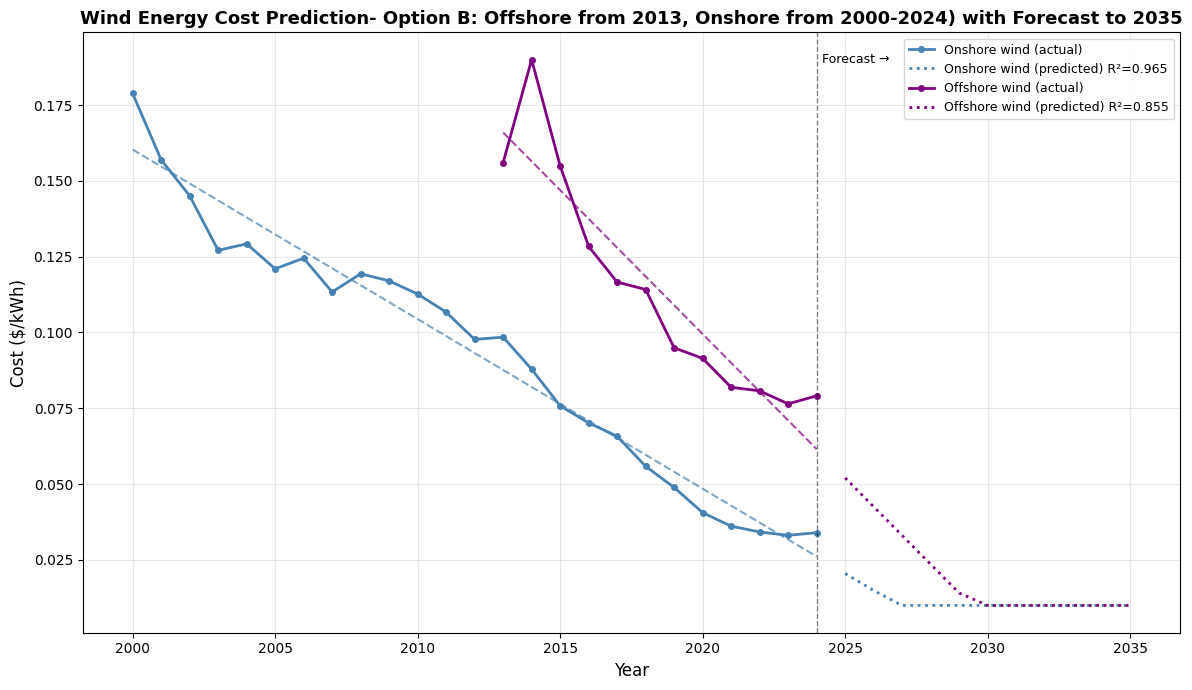

In [14]:
# Graph for results B (offshore between 2013-2024)

fig, ax = plt.subplots(figsize=(12, 7))

for tech, color in zip(technologies, ['steelblue', 'purple']):
    r = results_b[tech]

    # Plot actual data
    ax.plot(r['actual_years'], r['actual_prices'],
            marker='o', linewidth=2, color=color,
            label=f'{tech} (actual)', markersize=4)

    # Plot regression line over actual period
    X_line = pd.DataFrame(r['actual_years'], columns=['Year'])
    y_line = r['model'].predict(X_line)
    y_line = np.maximum(y_line, 0.01)
    ax.plot(r['actual_years'], y_line,
            linewidth=1.5, color=color, linestyle='--', alpha=0.7)

    # Plot future predictions
    ax.plot(r['future_years'], r['future_prices'],
            linewidth=2, color=color, linestyle=':',
            label=f'{tech} (predicted) R²={r["r2"]:.3f}')

# Vertical line at 2024
ax.axvline(x=2024, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax.text(2024.2, ax.get_ylim()[1] * 0.95, 'Forecast →', fontsize=9)

ax.set_title('Wind Energy Cost Prediction- Option B: Offshore from 2013, Onshore from 2000-2024) with Forecast to 2035',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Cost ($/kWh)', fontsize=12)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Analysis group 2 (5 other technologies)

In [15]:
# group 2 filtering dataset to 2010-2024

df_group2 = df_world[(df_world['Year'] >= 2010) & (df_world['Year'] <= 2024)].copy()

# selecting columns

df_group2 = df_group2[['Year', 'Bioenergy', 'Geothermal', 'Solar photovoltaic',
                       'Concentrated solar power', 'Hydropower']].copy()

print(df_group2.shape)
print(df_group2.isnull().sum())
print(df_group2)

(15, 6)
Year                        0
Bioenergy                   0
Geothermal                  1
Solar photovoltaic          0
Concentrated solar power    0
Hydropower                  0
dtype: int64
     Year  Bioenergy  Geothermal  Solar photovoltaic  \
837  2010   0.085815    0.055330            0.416956   
838  2011   0.082245         NaN            0.349902   
839  2012   0.070471    0.095286            0.260022   
840  2013   0.090375    0.070742            0.200221   
841  2014   0.090555    0.072156            0.182866   
842  2015   0.079670    0.064923            0.135105   
843  2016   0.077862    0.074959            0.118349   
844  2017   0.077739    0.078424            0.092945   
845  2018   0.059894    0.075690            0.078640   
846  2019   0.070283    0.074699            0.068642   
847  2020   0.079332    0.062747            0.061000   
848  2021   0.073505    0.075067            0.054526   
849  2022   0.063895    0.058841            0.051092   
850  2023   0.0

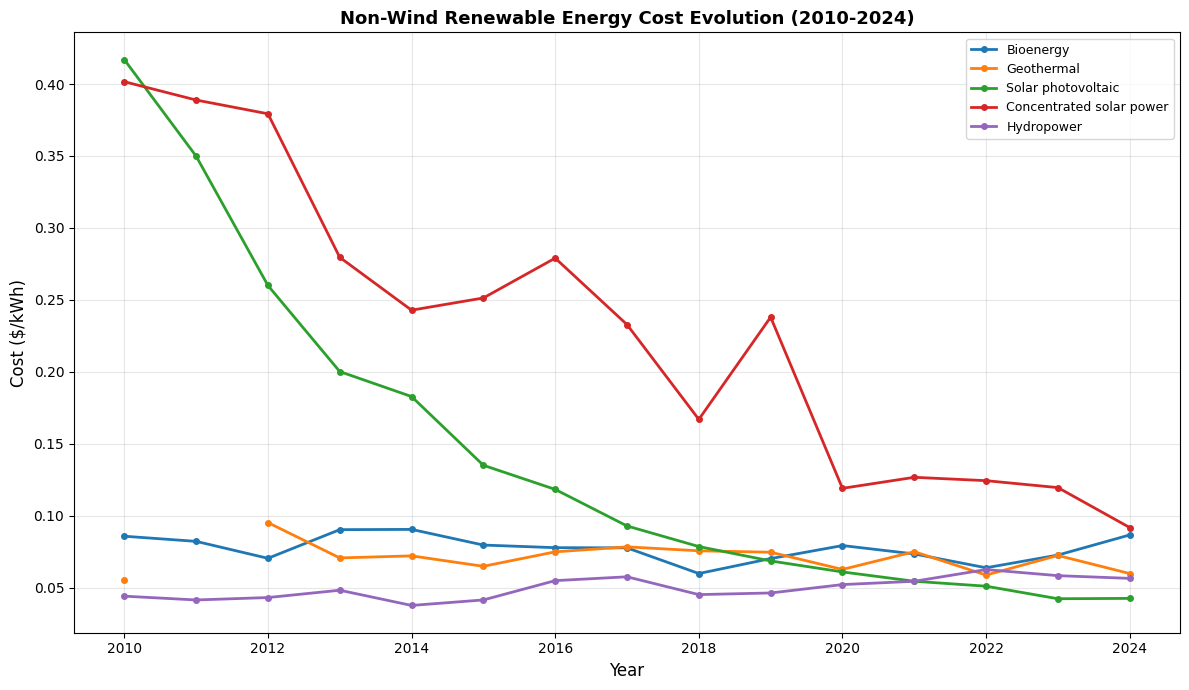

In [16]:
# visualizing df_group2

fig, ax = plt.subplots(figsize=(12, 7))

technologies_g2 = ['Bioenergy', 'Geothermal', 'Solar photovoltaic',
                    'Concentrated solar power', 'Hydropower']

for tech in technologies_g2:
    ax.plot(df_group2['Year'], df_group2[tech],
            marker='o', linewidth=2, label=tech, markersize=4)

ax.set_title('Non-Wind Renewable Energy Cost Evolution (2010-2024)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Cost ($/kWh)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

notes:

Concentrated solar power (csp) and solar photovoltaic (pv) are two different tech and cannot be compared 1on1. CSP is mostly projectbased and industrial, while pv is mostly for commercial use.

In [17]:

# GROUP 2 REGRESSION
future_years_g2 = np.arange(2025, 2036).reshape(-1, 1)
technologies_g2 = ['Bioenergy', 'Geothermal', 'Solar photovoltaic',
                    'Concentrated solar power', 'Hydropower']
results_g2 = {}

for tech in technologies_g2:
    df_tech = df_group2[['Year', tech]].dropna().copy()

    X = df_tech[['Year']]
    y = df_tech[tech]

    model = LinearRegression()
    model.fit(X, y)

    r2 = model.score(X, y)

    # Fix warning
    future_years_df = pd.DataFrame(future_years_g2, columns=['Year'])
    future_prices = model.predict(future_years_df)

    # Fix negative prices
    future_prices = np.maximum(future_prices, 0.01)

    results_g2[tech] = {
        'model': model,
        'r2': r2,
        'slope': model.coef_[0],
        'intercept': model.intercept_,
        'future_years': future_years_g2.flatten(),
        'future_prices': future_prices,
        'actual_years': df_tech['Year'].values,
        'actual_prices': y.values
    }

    print(f'\n── {tech} ──')
    print(f'R² score: {r2:.3f}')
    print(f'Slope: {model.coef_[0]:.6f} $/kWh per year')
    print(f'\nPredicted prices 2025-2035:')
    for year, price in zip(future_years_g2.flatten(), future_prices):
        print(f'  {year}: ${price:.4f}/kWh')


── Bioenergy ──
R² score: 0.152
Slope: -0.000792 $/kWh per year

Predicted prices 2025-2035:
  2025: $0.0711/kWh
  2026: $0.0703/kWh
  2027: $0.0695/kWh
  2028: $0.0687/kWh
  2029: $0.0679/kWh
  2030: $0.0671/kWh
  2031: $0.0663/kWh
  2032: $0.0655/kWh
  2033: $0.0647/kWh
  2034: $0.0639/kWh
  2035: $0.0632/kWh

── Geothermal ──
R² score: 0.053
Slope: -0.000543 $/kWh per year

Predicted prices 2025-2035:
  2025: $0.0667/kWh
  2026: $0.0661/kWh
  2027: $0.0656/kWh
  2028: $0.0651/kWh
  2029: $0.0645/kWh
  2030: $0.0640/kWh
  2031: $0.0634/kWh
  2032: $0.0629/kWh
  2033: $0.0623/kWh
  2034: $0.0618/kWh
  2035: $0.0613/kWh

── Solar photovoltaic ──
R² score: 0.816
Slope: -0.023683 $/kWh per year

Predicted prices 2025-2035:
  2025: $0.0100/kWh
  2026: $0.0100/kWh
  2027: $0.0100/kWh
  2028: $0.0100/kWh
  2029: $0.0100/kWh
  2030: $0.0100/kWh
  2031: $0.0100/kWh
  2032: $0.0100/kWh
  2033: $0.0100/kWh
  2034: $0.0100/kWh
  2035: $0.0100/kWh

── Concentrated solar power ──
R² score: 0.898


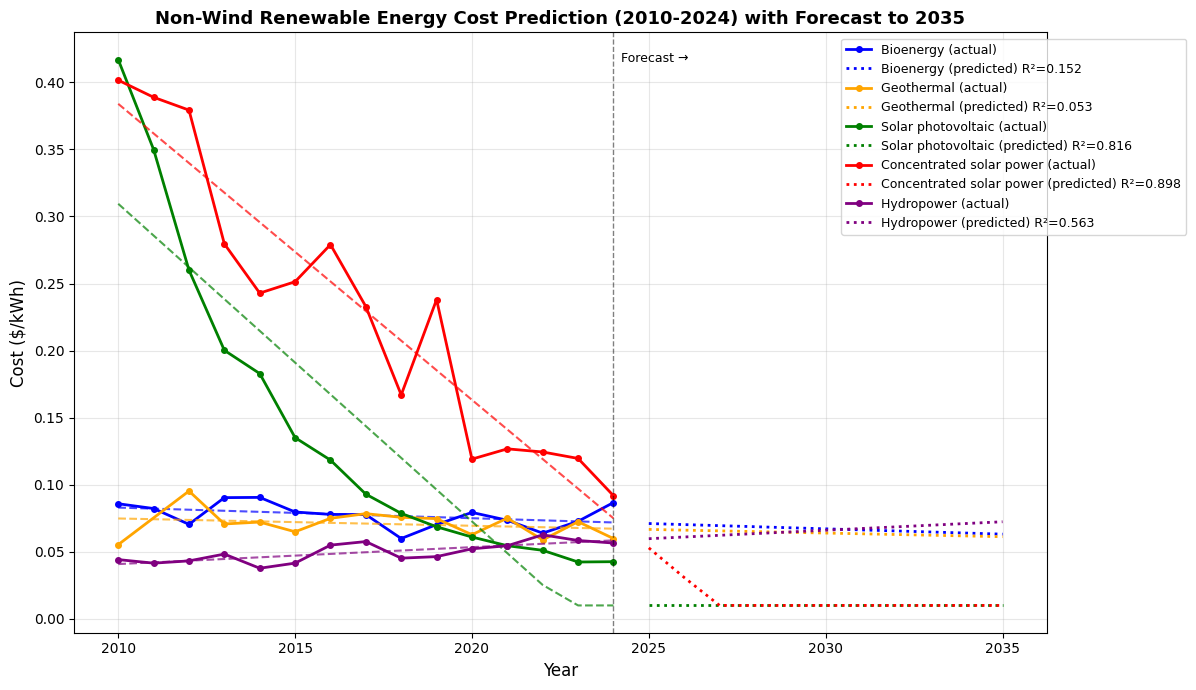

In [18]:
fig, ax = plt.subplots(figsize=(12, 7))

colors = ['blue', 'orange', 'green', 'red', 'purple']

for tech, color in zip(technologies_g2, colors):
    r = results_g2[tech]

    # Plot actual data
    ax.plot(r['actual_years'], r['actual_prices'],
            marker='o', linewidth=2, color=color,
            label=f'{tech} (actual)', markersize=4)

    # Plot regression line over actual period
    X_line = pd.DataFrame(r['actual_years'], columns=['Year'])
    y_line = r['model'].predict(X_line)
    y_line = np.maximum(y_line, 0.01)
    ax.plot(r['actual_years'], y_line,
            linewidth=1.5, color=color, linestyle='--', alpha=0.7)

    # Plot future predictions
    ax.plot(r['future_years'], r['future_prices'],
            linewidth=2, color=color, linestyle=':',
            label=f'{tech} (predicted) R²={r["r2"]:.3f}')

# Vertical line at 2024
ax.axvline(x=2024, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax.text(2024.2, ax.get_ylim()[1] * 0.95, 'Forecast →', fontsize=9)

ax.set_title('Non-Wind Renewable Energy Cost Prediction (2010-2024) with Forecast to 2035',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Cost ($/kWh)', fontsize=12)
ax.legend(fontsize=9, loc='upper right', bbox_to_anchor=(1.15, 1))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Conclusion Question 3**

Winners — hitting $0.01/kWh floor:

- Onshore wind (R²=0.965) — currently cheapest at $0.034/kWh, hits floor 2027
- Solar PV (R²=0.816) — fastest declining, hits floor 2025
- CSP (R²=0.898) — biggest surprise, hits floor 2027
Offshore wind (R²=0.855) — hits floor 2030

Mature/flat technologies:

- Geothermal (R²=0.053) — flat at $0.06/kWh
- Bioenergy (R²=0.152) — barely moving at $0.07/kWh
- Hydropower (R²=0.563) — actually rising to $0.072/kWh

Critical limitation:

LCOE measures generation cost only. Real total electricity cost includes storage, grid expansion and transmission, the next frontier for cost reduction after generation hits its floor.
